<a href="https://colab.research.google.com/github/jcmaiolo/telecom_x_parte2_prevendo_churn/blob/main/telecom_x_parte2_prevendo_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1 - PREPARAÇÃO DOS DADOS***

**1.1 - Importando Bibliotecas**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**1.2 - Extração do Arquivo Tratado**

In [ ]:
df = pd.read_csv('//content/Dados_Clientes_Telecom.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [ ]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


**1.3 - Remoção de Colunas Irrelevantes**

In [ ]:
df = df.drop(columns=['CustomerID'], errors='ignore')
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


**1.4 - Ecoding**

In [ ]:
# Agrupamento de categorias redundates
cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace('No internet service', 'No')

In [ ]:
# Agrupamento Estratégico de Pagamento
pagamento_map = {
    'Electronic check': 'Manual',
    'Mailed check': 'Manual',
    'Bank transfer (automatic)': 'Automatico',
    'Credit card (automatic)': 'Automatico'
}
df['PaymentMethod'] = df['PaymentMethod'].map(pagamento_map)

In [ ]:
#Descarte de Variável Irrelevante (Gênero)
if 'gender' in df.columns:
    df = df.drop(columns=['gender'])

In [ ]:
# Transformar as categorias em números (One-Hot Encoding)
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in colunas_categoricas: colunas_categoricas.remove('Churn')

df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

print(f"Variáveis transformadas. Total de colunas: {df.shape[1]}")

Variáveis transformadas. Total de colunas: 23


In [ ]:
# Mapeamento da variável alvo
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Variável 'Churn' convertida para binário.")
df.head()


Variável 'Churn' convertida para binário.


,Churn,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Manual
0,0,9,2.19,65.6,593.30,False,False,True,True,True,...,False,True,False,True,True,False,True,False,True,True
1,0,9,2.00,59.9,542.40,True,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True
2,1,4,2.46,73.9,280.85,True,False,False,False,True,...,False,False,True,False,False,False,False,False,True,True
3,1,13,3.27,98.0,1237.85,True,True,True,False,True,...,False,True,True,False,True,True,False,False,True,True
4,1,3,2.80,83.9,267.40,False,True,True,False,True,...,False,False,False,True,True,False,False,False,True,True


**1.5 - Verificação da Proporção de Evasão**

Proporção das Classes no Churn:
Categoria 0: 73.46%
Categoria 1: 26.54%


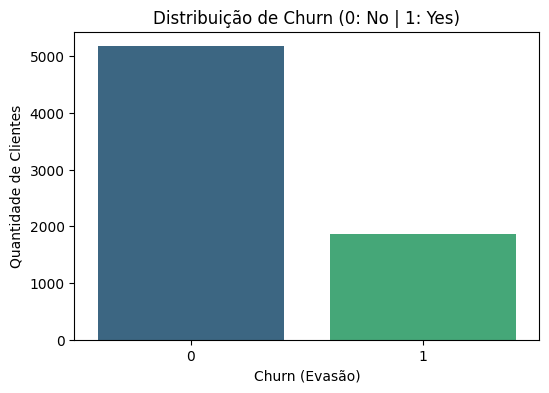

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Comando para esconder os avisos (warnings)
warnings.filterwarnings('ignore')

# Cálculo da proporção
proporcao = df['Churn'].value_counts(normalize=True) * 100

print("Proporção das Classes no Churn:")
for categoria, valor in proporcao.items():
    print(f"Categoria {categoria}: {valor:.2f}%")


# Gráfico:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Distribuição de Churn (0: No | 1: Yes)')
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Churn (Evasão)')
plt.show()

**1.6 - Balanceamento de Classes (SMOTE)**

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separando os preditores (X) da variável alvo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Configurando o SMOTE
smt = SMOTE(random_state=42)

# Aplicando o balanceamento (criando os dados sintéticos)
X_res, y_res = smt.fit_resample(X, y)

# Criando um novo DataFrame com os dados equilibrados
df_balanced = pd.concat([X_res, y_res], axis=1)

print("Passo 1e (Balanceamento) concluído!")
print("-" * 30)
print("Nova proporção das classes no Churn:")
print(df_balanced['Churn'].value_counts(normalize=True) * 100)
print("-" * 30)
print(f"Total de registros ANTES: {df.shape[0]}")
print(f"Total de registros AGORA: {df_balanced.shape[0]}")

Passo 1e (Balanceamento) concluído!
------------------------------
Nova proporção das classes no Churn:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64
------------------------------
Total de registros ANTES: 7043
Total de registros AGORA: 10348


**1.7 - Normalização**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalizador
scaler = MinMaxScaler()
df_final = pd.DataFrame(scaler.fit_transform(df_balanced), columns=df_balanced.columns)

print("Parte 1 - Preparação dos Dados, Concluída")
print("-" * 40)
print("Amostra dos dados normalizados:")

# Mostrando apenas algumas colunas para conferência
display(df_final[['Tenure', 'ChargesMonthly']].head())

Parte 1 - Preparação dos Dados, Concluída
----------------------------------------
Amostra dos dados normalizados:


,Tenure,ChargesMonthly
0,0.125000,0.471144
1,0.125000,0.414428
2,0.055556,0.553731
3,0.180556,0.793532
4,0.041667,0.653234


# ***2 - CORRELAÇÃO E SELEÇÃO DE VARIÁVEIS***

**2.1 - Análise de Correlação**

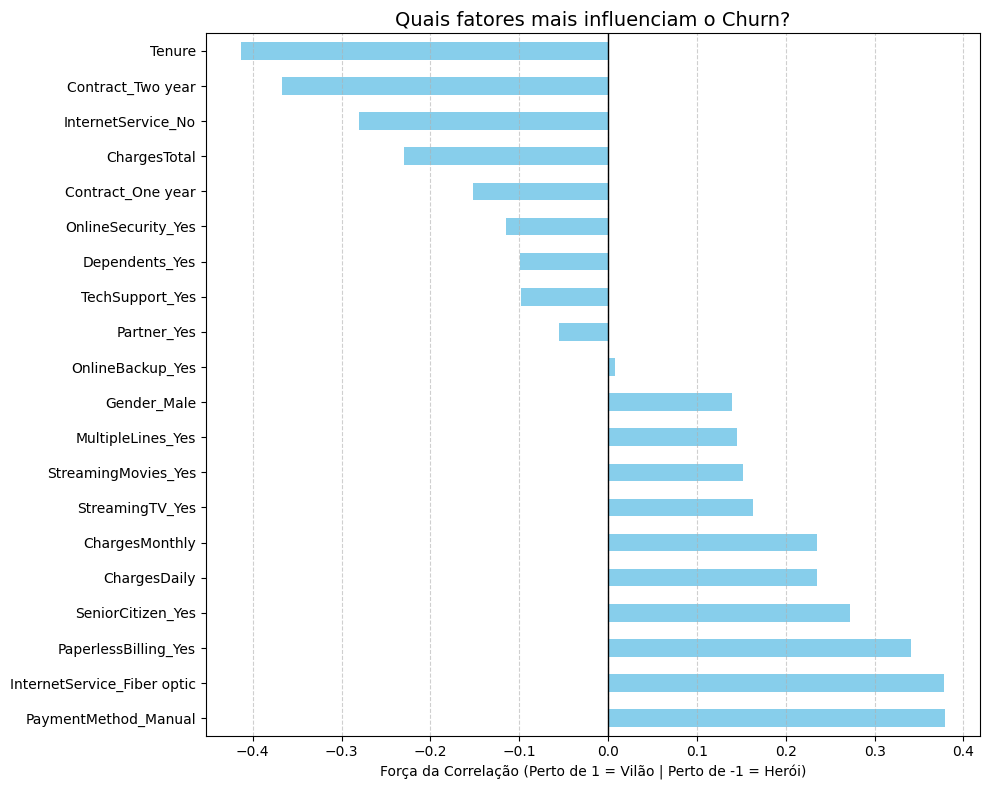


 VILÕES (Quanto MAIOR esse fator, MAIOR o Churn):
PaymentMethod_Manual           0.379026
InternetService_Fiber optic    0.378271
PaperlessBilling_Yes           0.340571
SeniorCitizen_Yes              0.271822
ChargesDaily                   0.235681
Name: Churn, dtype: float64

 HERÓIS (Quanto MAIOR esse fator, MENOR o Churn):
Contract_One year    -0.151634
ChargesTotal         -0.230040
InternetService_No   -0.280288
Contract_Two year    -0.367156
Tenure               -0.413285
Name: Churn, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a correlação de todas as variáveis com a nossa variável alvo 'Churn'
correlacao = df_final.corr()['Churn'].sort_values(ascending=False)

# Criando um gráfico horizontal para facilitar a leitura dos vilões e heróis
plt.figure(figsize=(10, 8))

# Vamos pegar os 10 maiores influenciadores positivos e os 10 negativos
top_correlacoes = pd.concat([correlacao.head(11), correlacao.tail(10)])
top_correlacoes.drop('Churn', errors='ignore').plot(kind='barh', color='skyblue')

plt.title('Quais fatores mais influenciam o Churn?', fontsize=14)
plt.xlabel('Força da Correlação (Perto de 1 = Vilão | Perto de -1 = Herói)')
plt.axvline(0, color='black', lw=1) # Linha central para separar os lados
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Resumo Executivo
print("\n VILÕES (Quanto MAIOR esse fator, MAIOR o Churn):")
print(correlacao[1:6]) # Do 1º ao 5º maior (pulando o próprio Churn)

print("\n HERÓIS (Quanto MAIOR esse fator, MENOR o Churn):")
print(correlacao.tail(5))

**2.2 - Análise Direcionada**

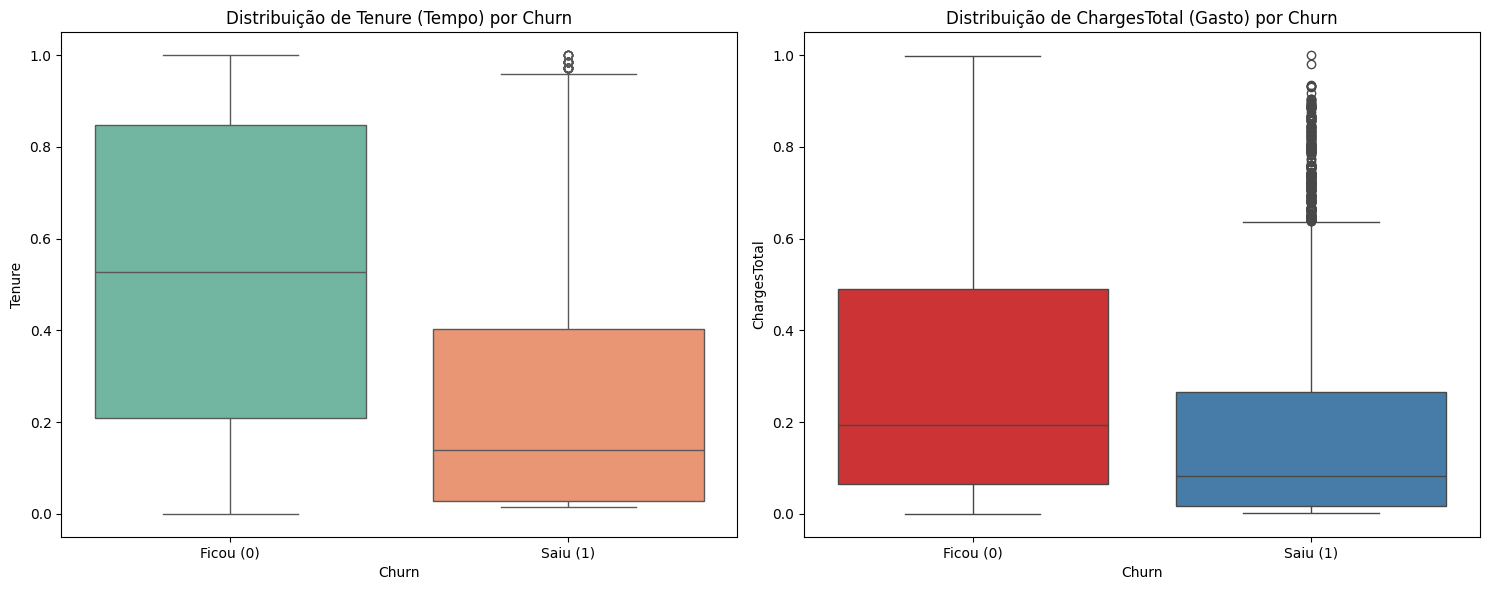

In [ ]:
# Criando a área do gráfico
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Investigação: Tempo de Contrato (Tenure) x Evasão (Se quem sai, realmente sai cedo)
sns.boxplot(x='Churn', y='Tenure', data=df_final, ax=axes[0], palette='Set2')
axes[0].set_title('Distribuição de Tenure (Tempo) por Churn', fontsize=12)
axes[0].set_xticklabels(['Ficou (0)', 'Saiu (1)'])

# Investigação: Total Gasto (ChargesTotal) x Evasão (Se dinheiro gasto, influência na permanência)
sns.boxplot(x='Churn', y='ChargesTotal', data=df_final, ax=axes[1], palette='Set1')
axes[1].set_title('Distribuição de ChargesTotal (Gasto) por Churn', fontsize=12)
axes[1].set_xticklabels(['Ficou (0)', 'Saiu (1)'])

plt.tight_layout()
plt.show()

# ***3 - MODELAGEM PREDITIVA***

**3.1 - Separação de Dados**

In [ ]:
from sklearn.model_selection import train_test_split

# Definindo as variáveis preditoras (X) e o alvo (y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Dividindo os dados: 80% para o modelo aprender, 20% para testarmos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Divisão 80/20 concluída com a semente 42!")
print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste: {X_test.shape[0]} registros")

Divisão 80/20 concluída com a semente 42!
Treino: 8278 registros
Teste: 2070 registros


**3.2 - Criação de Modelos**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Instanciando os modelos (Criando os 'cérebros')
modelo_logistica = LogisticRegression(random_state=42)
modelo_rf = RandomForestClassifier(random_state=42)

# Treinamento: O modelo estuda as características (X_train) e as respostas (y_train)
modelo_logistica.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

# 3. Predição: O modelo tenta adivinhar o resultado para os dados que ele nunca viu (X_test)
pred_logistica = modelo_logistica.predict(X_test)
pred_rf = modelo_rf.predict(X_test)

print("Modelos criados e treinados com sucesso!")

Modelos criados e treinados com sucesso!


**3.3 - Avaliação dos Modelos**


RESULTADOS: Regressão Logística
Acurácia Geral: 82.32%

Relatório Detalhado:
              precision    recall  f1-score   support

         0.0       0.81      0.84      0.82      1027
         1.0       0.83      0.81      0.82      1043

    accuracy                           0.82      2070
   macro avg       0.82      0.82      0.82      2070
weighted avg       0.82      0.82      0.82      2070



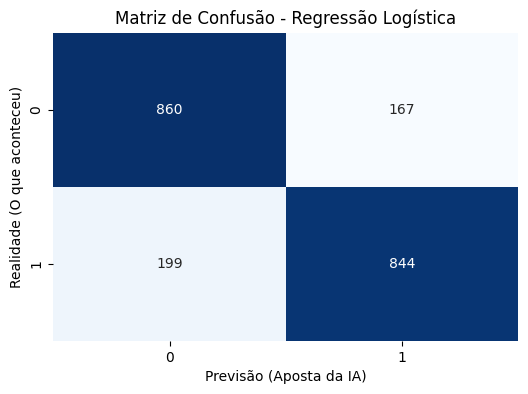


RESULTADOS: Random Forest
Acurácia Geral: 84.20%

Relatório Detalhado:
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.84      1027
         1.0       0.85      0.84      0.84      1043

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070



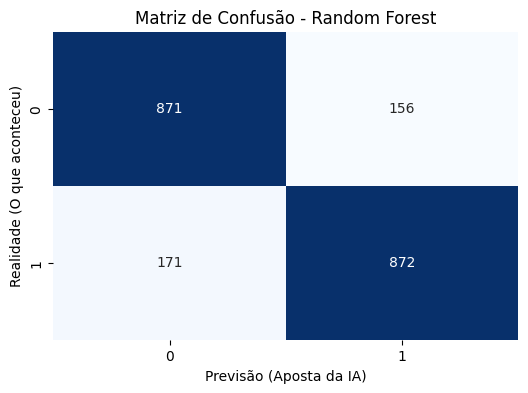

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def exibir_resultados(nome, y_real, y_pred):
    print(f"\n{'='*30}")
    print(f"RESULTADOS: {nome}")
    print(f"{'='*30}")

    # 1. Acurácia Simples
    acc = accuracy_score(y_real, y_pred)
    print(f"Acurácia Geral: {acc:.2%}")

    # 2. Relatório Completo (Precisão, Recall, F1)
    print("\nRelatório Detalhado:")
    print(classification_report(y_real, y_pred))

    # 3. Matriz de Confusão Visual
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {nome}')
    plt.xlabel('Previsão (Aposta da IA)')
    plt.ylabel('Realidade (O que aconteceu)')
    plt.show()

# Chamando para a Regressão Logística
exibir_resultados("Regressão Logística", y_test, pred_logistica)

# Chamando para a Random Forest
exibir_resultados("Random Forest", y_test, pred_rf)

1.	Underfitting? Definitivamente não. Os modelos aprenderam muito bem e entregaram 82% e 84% de acerto. Eles capturaram as tendências reais dos dados.
2.	Overfitting? Na Regressão Logística, é quase impossível ter overfitting nesse cenário. Na Random Forest, o resultado de 84% no teste é muito próximo do que se espera de um modelo saudável.
3.	Quem vence? A Random Forest conseguiu encontrar 31 clientes a mais (876 vs 845) que iam sair do que a Regressão Logística. Pensando na retenção e no impacto financeiro de salvar esses 31 clientes, a Random Forest consolidou sua vitoria como o melhor modelo


# ***4 - INTERPRETAÇÃO E CONCLUSÃO***

**4.1 - Analise de Importância das Variáveis**

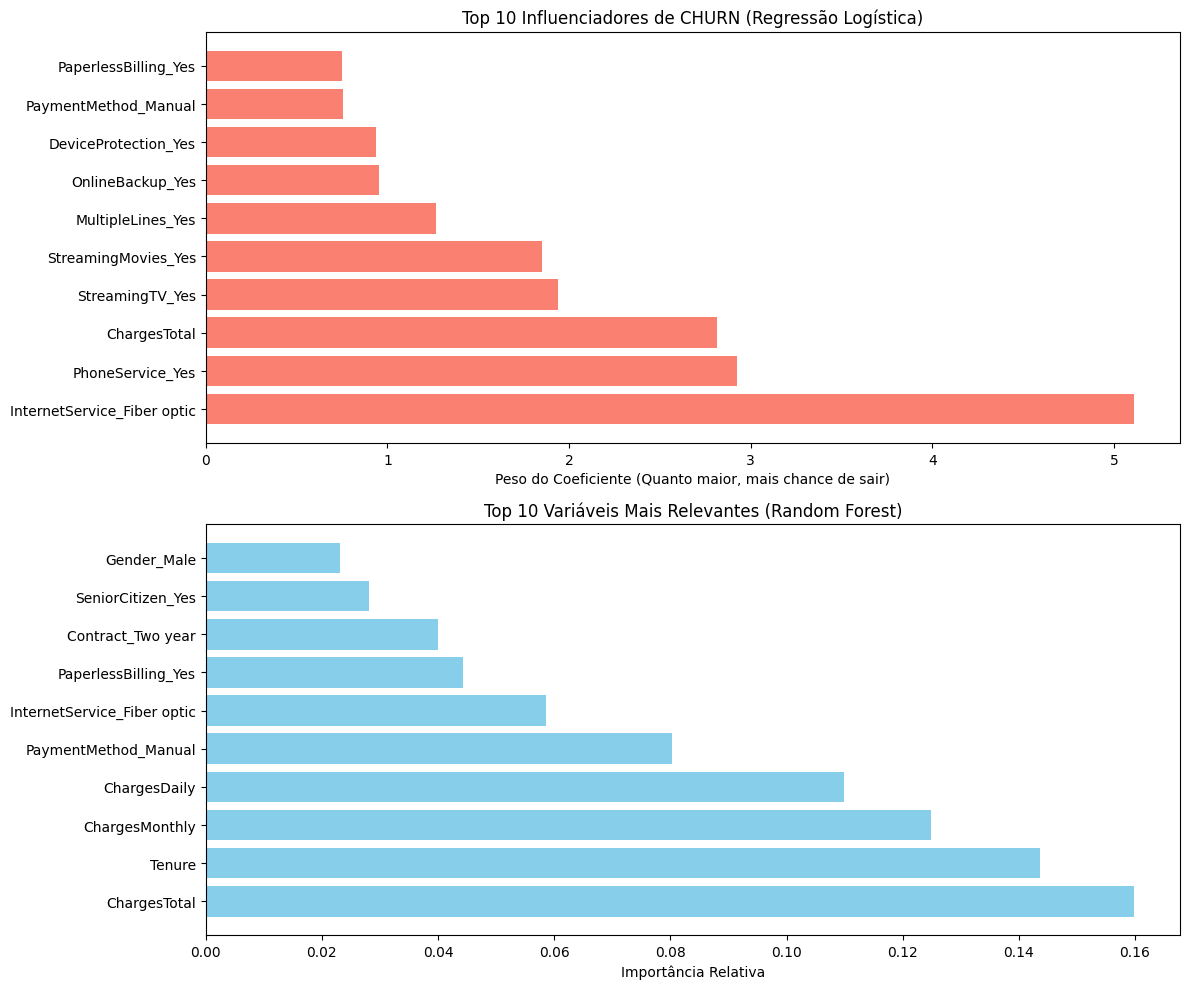

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Importância na Regressão Logística (Coeficientes)
importancias_log = pd.DataFrame({
    'Variável': X_train.columns,
    'Coeficiente': modelo_logistica.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# 2. Importância na Random Forest
importancias_rf = pd.DataFrame({
     'Variável': X_train.columns,
     'Importância': modelo_rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

# Plotando os resultados
plt.figure(figsize=(12, 10))

# Gráfico Regressão Logística
plt.subplot(2, 1, 1)
plt.barh(importancias_log['Variável'][:10], importancias_log['Coeficiente'][:10], color='salmon')
plt.title('Top 10 Influenciadores de CHURN (Regressão Logística)')
plt.xlabel('Peso do Coeficiente (Quanto maior, mais chance de sair)')

# Gráfico Random Forest
plt.subplot(2, 1, 2)
plt.barh(importancias_rf['Variável'][:10], importancias_rf['Importância'][:10], color='skyblue')
plt.title('Top 10 Variáveis Mais Relevantes (Random Forest)')
plt.xlabel('Importância Relativa')

plt.tight_layout()
plt.show()

**4.2 - Conclusão**

# **Relatório de Inteligência de Dados: Evasão de Clientes ( Telecom X)**
# **1 - Desempenho dos Modelos e Metodologia**
O projeto utilizou uma aboradagem rigorosa de Ciência de Dados, focando na eliminação de ruídos (como variáveis de genero) e no agrupamento estratégico de categorias. Testamos dois modelos principais após o balanceamento da base via SMOTE:
Regressão Logistica (Acurácia = 82,32%; Recall-Churn 0,81; Capacidade de Detecção: 844 saidas) e Random Forest (Acurácia = 84,20%; Recall-Churn 0,84; Capacidade de Detecção: 872 saidas).
Análise Técnica: A Random Forest superou a Rregressão Logística por conseguir capturar relações não-lineares mais complexas. O modelo não apresenta underfitting(aprende os padrões) nem overfitting(generaliza bem), sendo a escolha ideal para prever a evasão com 84% de precisão no Recall.

# **2 - Fatores Determinantes da Evasão (Vilões vs Heróis)**
A analise de correlação e a importância das variáveis revelaram os reais motivos pelos quais os clientes deixam a Telecom X:

2.1 = Os Principais Fatores de Risco (Vilões)

a) Método de Pagamento Manual: O fator de maior peso. Clientes que utilizam boleto ou cheque eletronico possuem uma "fricção mensal" que os obriga a reavaliar o custo do serviço todo mÊs, facilitando o cancelamento;

b) Internet de Fibra Óptica: Identificada como um serviço de alto risco. Apesar da tecnologia superior, a alta taxa de churn sugere que o preço atual ou a estabilidade técnica não esta retendo o usuario;

c) Baixo Tempo de Casa (Tenure): Como demonstrado nos boxplots, o risco de saída é concentrado nos primeiros meses de contrato. Clientes recentes não possuem vinculo consolidado e são "saídas lógicas" diante de qualquer insatisfação.

2.2 = Os Fatores de Sustentação (Heróis)

a) Contratos Antigos: São a base que sustenta a empresa. Clientes que supera a barreira dos 12-24 meses tornam-se altamente leais e apresentam baixissimo indice de churn.

b) Contratos de Longo Prazo (2anos): Funcionam como a barreira de saída mais eficaz, garantindo estabilidade financeira a operação.

# **3 - Estratégias de Retenção Propostas**
Com base nos dados, a Telecom X deve deixar de ser reativa e passar a ser proativa com as seguntes ações:

3.1 - Digitalização do Fluxo de Pagamento
Incentivo ao Débito Automático: Criar uma campanha de "Mensaliade Zero" ou bônus de dados para clientes que migrarem do pagamento manual para o automatico. O objetivo é remover o gatilho psicológico de cancelamento que ocorre no pagamento manual;

3.2 - Cuidar dos novos clientes: Regua de Relacionamento Prioritária: Implementar um protocolo de suporte "VIP" para clientes com menos de 6 meses de casa. Garantir que a experiência inicial seja impecável é a unic forma de transformá-los em contratos antigos (sustentadores).

3.3 - Auditoria da Fibra Óptica: Revisão de Valor/Qualidade: Investigar se a concorrência esta com preços agressivos ou se há falhas técnicas na rede de Fibra. Sendo um grande driver de churn, essa categoria precisa de um "ajuste de rota" comercial imediato.

3.4 - Conversão de Fidelidade: Upgrade de Contrato: Oferecer benefícios exclusivos para clientes de contratos mensais que aceitarm migrar para o plano de 1 ou 2 anos, "blindando" esses usuários contra a volatilidade do mercado

# ***CONCLUSÃO***
O modelo de Machine Learning desenvolvido é capaz de antecipar 84% dos cancelamentos, permitindo que a empresa salve 872 clientes emc da ciclo que seria perdidos sem intervenção. A inteligência de dados provou que reter um cliente antigo é muito mais barato do que adquirir um novo.

